# Large Dataset Benchmark — ChEMBL4649948

Severely imbalanced binary classification (~67:1 ratio, n=86 589).  
Two feature sets are compared:
- **Morgan**: 2 048-bit Morgan count fingerprints (integer, sparse)
- **Chemeleon**: 2 048-dim dense learned embeddings (float)

**Models:**
- `ZeroShotXGBClassifier` (portfolio=True) — zero-shot preset selection
- `XGBClassifier` defaults (n_estimators=100, scale_pos_weight corrected)
- `RandomForestClassifier` defaults (class_weight='balanced')

**Metrics:** AUROC, AUPR, train time  
**Protocol:** single stratified 80/20 train/test split

## 1. Load data

In [1]:
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

BASE = "../data/large/binary/chembl4649948_smiles_activity"

morgan    = np.load(f"{BASE}/morgan_descriptor.npy").astype(np.float32)
chemeleon = np.load(f"{BASE}/chemeleon_descriptor.npy").astype(np.float32)
df        = pd.read_csv(f"{BASE}/data.csv")
y         = df["activity"].values.astype(int)

pos = y.sum(); neg = (y == 0).sum()
print(f"n={len(y):,}  pos={pos:,}  neg={neg:,}  imbalance={neg/pos:.0f}:1")
print(f"Morgan    shape: {morgan.shape}    dtype: {morgan.dtype}")
print(f"Chemeleon shape: {chemeleon.shape}  dtype: {chemeleon.dtype}")

n=86,589  pos=1,268  neg=85,321  imbalance=67:1
Morgan    shape: (86589, 2048)    dtype: float32
Chemeleon shape: (86589, 2048)  dtype: float32


## 2. Dataset profiles

In [2]:
from sklearn.model_selection import train_test_split
from zsxgboost.inspector import inspect as profile_data

Xm_tr, Xm_te, ytr, yte = train_test_split(
    morgan, y, test_size=0.2, stratify=y, random_state=42
)
Xc_tr, Xc_te, _,   _   = train_test_split(
    chemeleon, y, test_size=0.2, stratify=y, random_state=42
)

print("=== MORGAN ===")
print(profile_data(Xm_tr, ytr, task="binary_classification"))
print()
print("=== CHEMELEON ===")
print(profile_data(Xc_tr, ytr, task="binary_classification"))

=== MORGAN ===


DatasetProfile(
  n_samples=69271, n_features=2048, n_p_ratio=33.82
  sparsity=0.971, is_sparse_counts=True
  binary_feature_fraction=0.395, feature_signal_strength=0.012
  task='binary_classification'
  imbalance_ratio=67.31
  feature_signal_p90=0.021
)

=== CHEMELEON ===


DatasetProfile(
  n_samples=69271, n_features=2048, n_p_ratio=33.82
  sparsity=0.563, is_sparse_counts=False
  binary_feature_fraction=0.056, feature_signal_strength=0.019
  task='binary_classification'
  imbalance_ratio=67.31
  feature_signal_p90=0.041
)


## 3. Preset cost analysis (a priori)

In [3]:
from zsxgboost.params import get_params
from zsxgboost.presets import xgb_default_params, flaml_params, autogluon_params, rf_params
from zsxgboost.model import _training_cost, _MAX_COST_MULTIPLIER

n_tr = len(ytr)

for desc, X_tr in [("Morgan", Xm_tr), ("Chemeleon", Xc_tr)]:
    prof = profile_data(X_tr, ytr, task="binary_classification")
    default_cost = _training_cost(xgb_default_params(prof, "cpu"), n_tr)
    budget = _MAX_COST_MULTIPLIER * default_cost
    print(f"=== {desc} (n_tr={n_tr:,}, p={prof.n_features}, "
          f"sparse_counts={prof.is_sparse_counts}) ===")
    print(f"  {'Preset':<12}  {'lr':>6}  {'patience':>8}  {'max_leaves':>10}  "
          f"{'cost':>10}  {'ratio':>7}  status")
    print("  " + "-"*70)
    for pname, pfn in [("internal", None), ("default", xgb_default_params),
                       ("flaml", flaml_params), ("autogluon", autogluon_params),
                       ("rf_like", rf_params)]:
        p = pfn(prof, "cpu") if pfn else get_params(prof, "cpu")
        cost = _training_cost(p, n_tr)
        ratio = cost / default_cost
        ml = p.get("max_leaves", 2 ** p.get("max_depth", 6))
        skip = pname not in ("internal", "default") and cost > budget
        status = "SKIP (cost)" if skip else "run"
        print(f"  {pname:<12}  {p['learning_rate']:>6.4f}  "
              f"{p['early_stopping_rounds']:>8}  {ml:>10}  "
              f"{cost:>10.2e}  {ratio:>6.1f}x  {status}")
    print()

=== Morgan (n_tr=69,271, p=2048, sparse_counts=True) ===
  Preset            lr  patience  max_leaves        cost    ratio  status
  ----------------------------------------------------------------------
  internal      0.1000        50         256    1.77e+09     6.1x  run
  default       0.3000        50          64    2.93e+08     1.0x  run
  flaml         0.0070       200          64    8.87e+09    30.3x  SKIP (cost)
  autogluon     0.0180       200          64    5.81e+09    19.9x  run
  rf_like       0.1000        50          64    4.43e+08     1.5x  run



=== Chemeleon (n_tr=69,271, p=2048, sparse_counts=False) ===
  Preset            lr  patience  max_leaves        cost    ratio  status
  ----------------------------------------------------------------------
  internal      0.0500       100          32    6.65e+08     2.3x  run
  default       0.3000        50          64    2.93e+08     1.0x  run
  flaml         0.0070       200          64    8.87e+09    30.3x  SKIP (cost)
  autogluon     0.0290       172          64    3.39e+09    11.6x  run
  rf_like       0.1000        50          64    4.43e+08     1.5x  run



## 4. Train and evaluate all models

In [ ]:
import time
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from zsxgboost import ZeroShotXGBClassifier

imb = (y == 0).sum() / y.sum()

results = {}  # desc -> model_name -> dict

model_defs = {
    "zs-xgboost":  lambda: ZeroShotXGBClassifier(portfolio=True, verbose=True),
    "xgb-default": lambda: xgb.XGBClassifier(
        n_estimators=100, tree_method="hist", nthread=-1, verbosity=0,
        scale_pos_weight=imb, eval_metric="aucpr"),
    "rf-default":  lambda: RandomForestClassifier(
        n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42),
}

for desc, X_tr, X_te in [("Morgan", Xm_tr, Xm_te), ("Chemeleon", Xc_tr, Xc_te)]:
    results[desc] = {}
    print(f"\n{'='*60}")
    print(f"  {desc}")
    print(f"{'='*60}")
    for mname, clf_fn in model_defs.items():
        print(f"\n--- {mname} ---")
        clf = clf_fn()
        t0 = time.perf_counter()
        clf.fit(X_tr, ytr)
        elapsed = time.perf_counter() - t0
        proba = clf.predict_proba(X_te)[:, 1]
        auroc = roc_auc_score(yte, proba)
        aupr  = average_precision_score(yte, proba)
        fpr, tpr, _ = roc_curve(yte, proba)
        prec, rec, _ = precision_recall_curve(yte, proba)
        preset = getattr(clf, "preset_name_", "-")
        results[desc][mname] = dict(
            auroc=auroc, aupr=aupr, time=elapsed,
            preset=preset, fpr=fpr, tpr=tpr, prec=prec, rec=rec
        )
        print(f"  AUROC={auroc:.4f}  AUPR={aupr:.4f}  time={elapsed:.1f}s  preset={preset}")

        # Print portfolio selection detail for zs-xgboost
        scores = getattr(clf, "portfolio_scores_", {})
        if scores:
            default_score = scores.get("default", float("nan"))
            print(f"\n  Portfolio scores (val AUC, higher = better):")
            for pname, sc in sorted(scores.items(), key=lambda x: -x[1]):
                marker = " ← selected" if pname == preset else ""
                gain   = f"  gain vs default: {sc - default_score:+.4f}" if pname != "default" else ""
                print(f"    {pname:<12}  {sc:.4f}{gain}{marker}")


## 5. Summary table

In [5]:
rows = []
for desc in results:
    for mname, r in results[desc].items():
        rows.append({
            "Descriptors": desc,
            "Model": mname,
            "AUROC": round(r["auroc"], 4),
            "AUPR":  round(r["aupr"],  4),
            "Time (s)": round(r["time"], 1),
            "Preset": r["preset"],
        })

summary = pd.DataFrame(rows).set_index(["Descriptors", "Model"])
print(summary.to_string())

                          AUROC    AUPR  Time (s)    Preset
Descriptors Model                                          
Morgan      zs-xgboost   0.7760  0.1033      50.7  internal
            xgb-default  0.7415  0.0795       2.8         -
            rf-default   0.7549  0.0995       5.6         -
Chemeleon   zs-xgboost   0.7772  0.0809     203.8   default
            xgb-default  0.7600  0.1051      19.6         -
            rf-default   0.7591  0.0885      14.1         -


## 6. ROC and PR curves

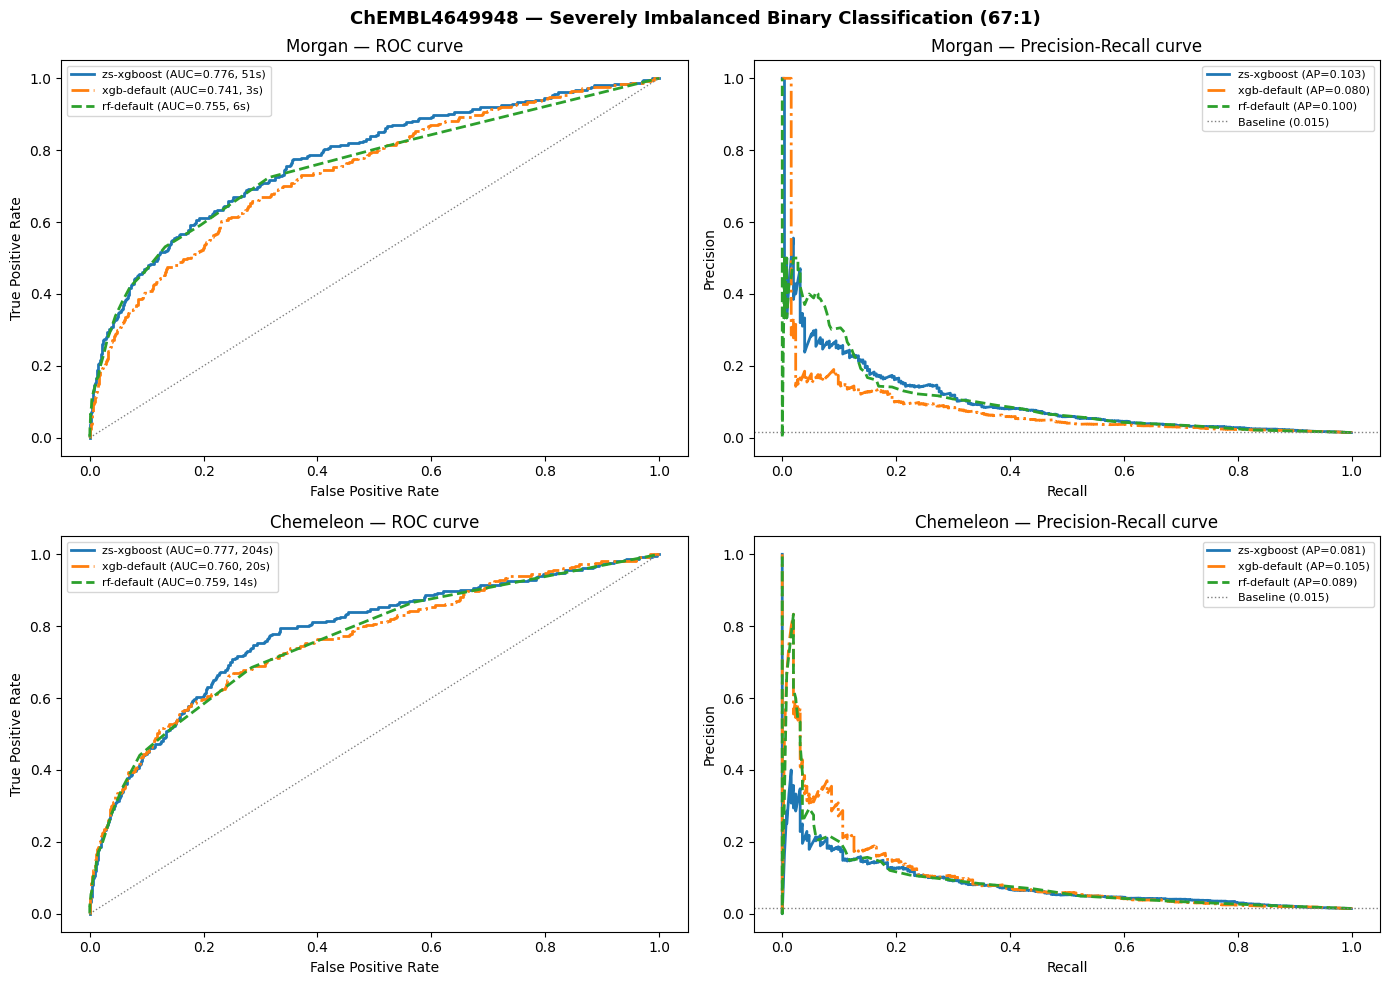

In [6]:
import matplotlib.pyplot as plt

colors = {"zs-xgboost": "tab:blue", "xgb-default": "tab:orange", "rf-default": "tab:green"}
styles = {"zs-xgboost": "-",        "xgb-default": "-.",         "rf-default": "--"}
baseline_pr = yte.mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, desc in enumerate(["Morgan", "Chemeleon"]):
    ax_roc = axes[row_idx, 0]
    ax_pr  = axes[row_idx, 1]

    for mname, r in results[desc].items():
        lbl_roc = f"{mname} (AUC={r['auroc']:.3f}, {r['time']:.0f}s)"
        lbl_pr  = f"{mname} (AP={r['aupr']:.3f})"
        ax_roc.plot(r["fpr"], r["tpr"], lw=2, color=colors[mname],
                    linestyle=styles[mname], label=lbl_roc)
        ax_pr.plot(r["rec"], r["prec"], lw=2, color=colors[mname],
                   linestyle=styles[mname], label=lbl_pr)

    ax_roc.plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f"{desc} — ROC curve")
    ax_roc.legend(fontsize=8)

    ax_pr.axhline(baseline_pr, linestyle=":", color="grey", lw=1,
                  label=f"Baseline ({baseline_pr:.3f})")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title(f"{desc} — Precision-Recall curve")
    ax_pr.legend(fontsize=8)

plt.suptitle("ChEMBL4649948 — Severely Imbalanced Binary Classification (67:1)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Training time comparison

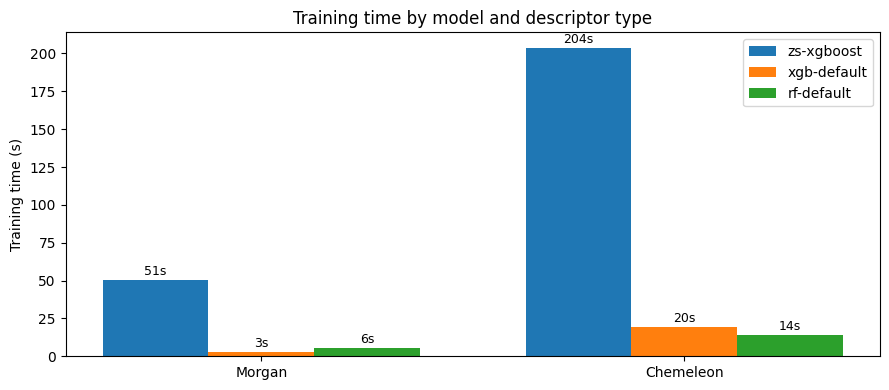

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

descs = ["Morgan", "Chemeleon"]
mnames = list(model_defs.keys())
x = np.arange(len(descs))
width = 0.25

for i, mname in enumerate(mnames):
    times = [results[d][mname]["time"] for d in descs]
    bars = ax.bar(x + i * width, times, width, label=mname,
                  color=list(colors.values())[i])
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{t:.0f}s", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(descs)
ax.set_ylabel("Training time (s)")
ax.set_title("Training time by model and descriptor type")
ax.legend()
plt.tight_layout()
plt.show()